# CS-4063 Assignment 3: Scratch-Built Transformers + RAG

**Student ID:** i232573  
**Execution target:** Kaggle Notebooks with GPU acceleration

## How to run this notebook

1. Upload this notebook to Kaggle together with the `Dataset/`, `models/`, and `results/` folders.
2. Turn on the GPU accelerator in Kaggle before running the training cells.
3. Run the notebook from top to bottom exactly once so that vocabularies, checkpoints, embeddings, retrieval outputs, and generated explanations stay consistent.
4. The notebook saves trained weights into `models/` and evaluation artifacts into `results/` as required by the assignment.

## Assignment-specific notes

- The handout title is **Assignment 3**, but the naming convention line says `Assignment2`. This notebook keeps the handout naming convention in the filename while implementing the Assignment 3 pipeline.
- You asked to use **all five product categories**. To keep the combined dataset inside the assignment's overall 30k-45k target range, the default configuration samples **8000 reviews per category** for a total target size of about **40,000 reviews**.
- The second encoder task is **review length bucket prediction** with three labels: **Short**, **Medium**, and **Long**, derived from tokenized review length.
- Since Amazon Reviews does not provide gold explanations, the decoder is trained on **rule-based reference explanations** generated from the structured inputs inside this notebook.
- Both the encoder-only and decoder-only Transformer implementations below are built **from scratch** using only basic PyTorch layers. The forbidden high-level Transformer abstractions from the assignment are not used.

## Notebook roadmap

This notebook covers:

1. Environment setup and reproducibility
2. Dataset loading, cleaning, splitting, and vocabulary building
3. A scratch-built encoder-only Transformer for multi-task learning
4. Embedding extraction and cosine-similarity retrieval
5. A scratch-built decoder-only Transformer for explanation generation
6. Perplexity evaluation, qualitative examples, and a no-retrieval ablation
7. Bonus interactive visualization with Gradio

In [10]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "torch": "torch",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
    "gradio": "gradio",
}
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

import gc
import gzip
import json
import math
import random
import re
import time
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 180)


@dataclass
class Config:
    student_id: str = "i232573"
    seed: int = 42
    reviews_per_category: int = 8000
    encoder_max_len: int = 160
    decoder_max_len: int = 320
    max_generation_len: int = 48
    top_k: int = 3
    encoder_batch_size: int = 64
    decoder_batch_size: int = 32
    encoder_epochs: int = 4
    decoder_epochs: int = 4
    d_model: int = 256
    num_heads: int = 8
    num_layers: int = 4
    ff_multiplier: int = 4
    dropout: float = 0.1
    encoder_lr: float = 3e-4
    decoder_lr: float = 3e-4
    weight_decay: float = 1e-2
    min_freq: int = 3
    gradient_clip: float = 1.0
    length_short_threshold: int = 40
    length_long_threshold: int = 120
    retrieval_chunk_size: int = 512
    review_context_words: int = 80
    retrieved_context_words: int = 40


CONFIG = Config()
CATEGORY_FILES = {
    "beauty": ["beauty.json.gz", "Beauty_5.json.gz", "beauty.json", "Beauty_5.json"],
    "cellphones": [
        "cellphones.json.gz",
        "Cell_Phones_and_Accessories_5.json.gz",
        "cellphones.json",
        "Cell_Phones_and_Accessories_5.json",
    ],
    "electronics": ["electronics.json.gz", "Electronics_5.json.gz", "electronics.json", "Electronics_5.json"],
    "home": ["home.json.gz", "Home_and_Kitchen_5.json.gz", "home.json", "Home_and_Kitchen_5.json"],
    "sports": ["sports.json.gz", "Sports_and_Outdoors_5.json.gz", "sports.json", "Sports_and_Outdoors_5.json"],
}

PROJECT_ROOT = Path.cwd()


def _find_data_root() -> Path:
    candidates = [
        PROJECT_ROOT / "Dataset" / "Dataset",
        PROJECT_ROOT / "Dataset",
        Path("/kaggle/input"),
        PROJECT_ROOT,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate a dataset root directory.")


DATA_DIR = _find_data_root()

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CONFIG.seed)

print("Project root  :", PROJECT_ROOT)
print("Dataset root  :", DATA_DIR)
print("Running on    :", DEVICE)
print("Configuration:")
display(pd.DataFrame([asdict(CONFIG)]))

Project root  : /kaggle/working
Dataset root  : /kaggle/input
Running on    : cuda
Configuration:


,student_id,seed,reviews_per_category,encoder_max_len,decoder_max_len,max_generation_len,top_k,encoder_batch_size,decoder_batch_size,encoder_epochs,...,encoder_lr,decoder_lr,weight_decay,min_freq,gradient_clip,length_short_threshold,length_long_threshold,retrieval_chunk_size,review_context_words,retrieved_context_words
0,i232573,42,8000,160,320,48,3,64,32,4,...,0.0003,0.0003,0.01,3,1.0,40,120,512,80,40


## 1. Environment Setup and Run Configuration
## 2. Imports, Paths, and Reproducibility

The previous code cell defines all configurable hyperparameters, output paths, and reproducibility controls.

## 3. Dataset Loading and Category Subset Construction
## 4. Train, Validation, and Test Split
## 5. Text Cleaning and Label Mapping
## 6. Tokenizer, Vocabulary, and Numerical Encoding
## 7. Padding, Truncation, and Batch Collation
## 8. Derived Feature Definition and Target Preparation
## 9. PyTorch Dataset and DataLoader Construction

The next cells implement the full preprocessing pipeline required by the assignment:

- streaming review loading from the compressed Amazon review files
- review cleaning and tokenization
- three-class sentiment mapping from star ratings
- the derived review-length bucket target
- a training-only vocabulary
- fixed-length numerical encoding with padding and truncation
- dataset and dataloader objects for both the encoder and decoder stages

In [11]:
TOKEN_PATTERN = re.compile(r"<[^>]+>|[a-z0-9']+|[.,!?;:]")
HTML_TAG_RE = re.compile(r"<[^>]+>")
WHITESPACE_RE = re.compile(r"\s+")

STOPWORDS = {
    "a", "about", "after", "again", "all", "also", "am", "an", "and", "any", "are", "as", "at", "be", "because",
    "been", "before", "being", "but", "by", "can", "could", "did", "do", "does", "for", "from", "get", "got",
    "had", "has", "have", "he", "her", "here", "hers", "him", "his", "how", "i", "if", "in", "into", "is",
    "it", "its", "itself", "just", "me", "more", "most", "my", "no", "not", "now", "of", "on", "one", "only",
    "or", "our", "out", "over", "really", "she", "so", "some", "than", "that", "the", "their", "them", "then",
    "there", "these", "they", "this", "those", "to", "too", "up", "very", "was", "we", "were", "what", "when",
    "which", "while", "who", "will", "with", "would", "you", "your",
}

SENTIMENT_TO_ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID_TO_SENTIMENT = {index: label for label, index in SENTIMENT_TO_ID.items()}
LENGTH_TO_ID = {"Short": 0, "Medium": 1, "Long": 2}
ID_TO_LENGTH = {index: label for label, index in LENGTH_TO_ID.items()}


def clean_text(text: str) -> str:
    text = "" if text is None else str(text)
    text = HTML_TAG_RE.sub(" ", text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = text.encode("ascii", "ignore").decode("ascii")
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text


def tokenize(text: str) -> list[str]:
    return TOKEN_PATTERN.findall(clean_text(text).lower())


def map_sentiment(rating: float) -> str:
    rating = int(round(float(rating)))
    if rating <= 2:
        return "Negative"
    if rating == 3:
        return "Neutral"
    return "Positive"


def map_length_bucket(review_text: str) -> tuple[str, int]:
    token_count = len(tokenize(review_text))
    if token_count < CONFIG.length_short_threshold:
        return "Short", token_count
    if token_count <= CONFIG.length_long_threshold:
        return "Medium", token_count
    return "Long", token_count


def phrase_from_terms(terms: list[str]) -> str:
    filtered_terms = [term for term in terms if term]
    if not filtered_terms:
        return "clear product details"
    if len(filtered_terms) == 1:
        return filtered_terms[0]
    return ", ".join(filtered_terms[:-1]) + f" and {filtered_terms[-1]}"


def extract_salient_terms(review_text: str, limit: int = 2) -> list[str]:
    candidate_tokens = [token for token in tokenize(review_text) if token.isalpha() and token not in STOPWORDS and len(token) > 2]
    if not candidate_tokens:
        return ["product experience"]
    ranked = [token for token, _ in Counter(candidate_tokens).most_common(limit)]
    return ranked


def shorten_text(review_text: str, max_words: int) -> str:
    return " ".join(tokenize(review_text)[:max_words])


def build_reference_explanation(review_text: str, sentiment_label: str, length_bucket: str) -> str:
    cues = phrase_from_terms(extract_salient_terms(review_text, limit=2))
    sentiment_reason = {
        "Positive": "overall satisfaction and a favorable product experience",
        "Neutral": "mixed evidence without a strong positive or negative signal",
        "Negative": "dissatisfaction and a clearly unfavorable experience",
    }
    length_reason = {
        "Short": "The review is short, but the signal is still direct and clear.",
        "Medium": "The review provides a moderate amount of detail to justify the label.",
        "Long": "The review is long enough to include several supporting details for the label.",
    }
    return (
        f"This review is {sentiment_label.lower()} because it mentions {cues}, suggesting "
        f"{sentiment_reason[sentiment_label]}. {length_reason[length_bucket]}"
    )


def resolve_category_file(data_root: Path, category_name: str, filename_hints: list[str]) -> Path:
    exact_matches = []
    for filename_hint in filename_hints:
        exact_matches.extend(path for path in data_root.rglob(filename_hint) if path.is_file())
    if exact_matches:
        return sorted(exact_matches, key=lambda path: (len(str(path)), str(path)))[0]

    normalized_category = re.sub(r"[^a-z0-9]+", "", category_name.lower())
    fallback_matches = []
    for path in data_root.rglob("*.json*"):
        if path.is_file():
            normalized_path = re.sub(r"[^a-z0-9]+", "", path.as_posix().lower())
            if normalized_category in normalized_path:
                fallback_matches.append(path)
    if fallback_matches:
        return sorted(fallback_matches, key=lambda path: (len(str(path)), str(path)))[0]

    raise FileNotFoundError(
        f"Could not locate a file for category '{category_name}' under {data_root}.\n"
        f"Tried hints: {filename_hints}"
    )


def open_review_file(path: Path):
    if path.suffix == ".gz":
        return gzip.open(path, "rt", encoding="utf-8")
    return path.open("rt", encoding="utf-8")


def reservoir_sample_reviews(path: Path, category_name: str, sample_size: int, rng: random.Random) -> list[dict]:
    sampled_reviews: list[dict] = []
    seen = 0
    with open_review_file(path) as handle:
        for line in tqdm(handle, desc=f"Sampling {category_name}", leave=False):
            record = json.loads(line)
            review_text = clean_text(record.get("reviewText", ""))
            rating = record.get("overall")
            if not review_text or rating is None:
                continue
            if len(tokenize(review_text)) < 5:
                continue
            row = {
                "category": category_name,
                "review_text": review_text,
                "rating": int(round(float(rating))),
            }
            seen += 1
            if len(sampled_reviews) < sample_size:
                sampled_reviews.append(row)
                continue
            replacement_index = rng.randint(0, seen - 1)
            if replacement_index < sample_size:
                sampled_reviews[replacement_index] = row
    return sampled_reviews


def build_dataset_subset(data_dir: Path, category_files: dict[str, list[str]], sample_size: int, seed: int) -> pd.DataFrame:
    rng = random.Random(seed)
    collected_rows: list[dict] = []
    resolved_paths = {}
    for category_name, filename_hints in category_files.items():
        category_path = resolve_category_file(data_dir, category_name, filename_hints)
        resolved_paths[category_name] = str(category_path)
        category_rows = reservoir_sample_reviews(category_path, category_name, sample_size, rng)
        collected_rows.extend(category_rows)
    print("Resolved category files:")
    display(pd.DataFrame({"category": list(resolved_paths.keys()), "path": list(resolved_paths.values())}))
    dataframe = pd.DataFrame(collected_rows).drop_duplicates(subset=["review_text"]).reset_index(drop=True)
    dataframe["review_id"] = np.arange(len(dataframe))
    dataframe["sentiment_label"] = dataframe["rating"].map(map_sentiment)
    length_info = dataframe["review_text"].map(map_length_bucket)
    dataframe["length_bucket"] = [bucket for bucket, _ in length_info]
    dataframe["word_count"] = [count for _, count in length_info]
    dataframe["sentiment_id"] = dataframe["sentiment_label"].map(SENTIMENT_TO_ID)
    dataframe["length_id"] = dataframe["length_bucket"].map(LENGTH_TO_ID)
    return dataframe


def stratified_three_way_split(dataframe: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    temp_df = dataframe.copy()
    temp_df["stratify_key"] = temp_df["category"] + "__" + temp_df["sentiment_label"]
    train_df, remainder_df = train_test_split(
        temp_df,
        test_size=0.30,
        random_state=seed,
        stratify=temp_df["stratify_key"],
    )
    remainder_df = remainder_df.copy()
    remainder_df["stratify_key"] = remainder_df["category"] + "__" + remainder_df["sentiment_label"]
    val_df, test_df = train_test_split(
        remainder_df,
        test_size=0.50,
        random_state=seed,
        stratify=remainder_df["stratify_key"],
    )
    return (
        train_df.drop(columns=["stratify_key"]).reset_index(drop=True),
        val_df.drop(columns=["stratify_key"]).reset_index(drop=True),
        test_df.drop(columns=["stratify_key"]).reset_index(drop=True),
    )


def split_summary(dataframe: pd.DataFrame, split_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "split": [split_name],
            "rows": [len(dataframe)],
            "negative": [(dataframe["sentiment_label"] == "Negative").sum()],
            "neutral": [(dataframe["sentiment_label"] == "Neutral").sum()],
            "positive": [(dataframe["sentiment_label"] == "Positive").sum()],
            "short": [(dataframe["length_bucket"] == "Short").sum()],
            "medium": [(dataframe["length_bucket"] == "Medium").sum()],
            "long": [(dataframe["length_bucket"] == "Long").sum()],
            "avg_words": [round(float(dataframe["word_count"].mean()), 2)],
        }
    )

Sampling beauty: 0it [00:00, ?it/s]

Sampling cellphones: 0it [00:00, ?it/s]

Sampling electronics: 0it [00:00, ?it/s]

Sampling home: 0it [00:00, ?it/s]

Sampling sports: 0it [00:00, ?it/s]

...

,split,rows,negative,neutral,positive,short,medium,long,avg_words
0,full,39995,4071,3780,32144,11737,17661,10597,110.35
1,train,27996,2849,2647,22500,8229,12389,7378,110.15
2,validation,5999,612,567,4820,1743,2657,1599,109.53
3,test,6000,610,566,4824,1765,2615,1620,112.15


Category counts after sampling and deduplication


,category,rows
0,beauty,7999
1,cellphones,8000
2,electronics,7997
3,home,8000
4,sports,7999


Example reviews


,category,rating,sentiment_label,length_bucket,review_text
0,beauty,4,Positive,Long,I switched to a mineral sunscreen after finding that chemical sunscreens were to harsh for my face. I'm light skinned African American and this works well for me. However if I ...
1,beauty,3,Neutral,Medium,I received this nail polish a couple of days ago love the color but make sure you put a few coats of nail hardner it chipped the next day so I say it's so so but I love the col...
2,beauty,2,Negative,Short,I did the directions but used a smaller amount. ive done this mask about 5 times and absolutely nothing has happened...
3,beauty,5,Positive,Medium,"I love these. Some evenings after a long day at work and school, I get home late and am too exhausted to spend all kinds of time removing makeup. Makeup removal is a snap using..."
4,beauty,5,Positive,Long,"Ever since buying this ""Perfume"" years ago I have had to have it daily! I'll tell you why. Since I have been using this fragrance I have had nothing but fantastic comments from..."


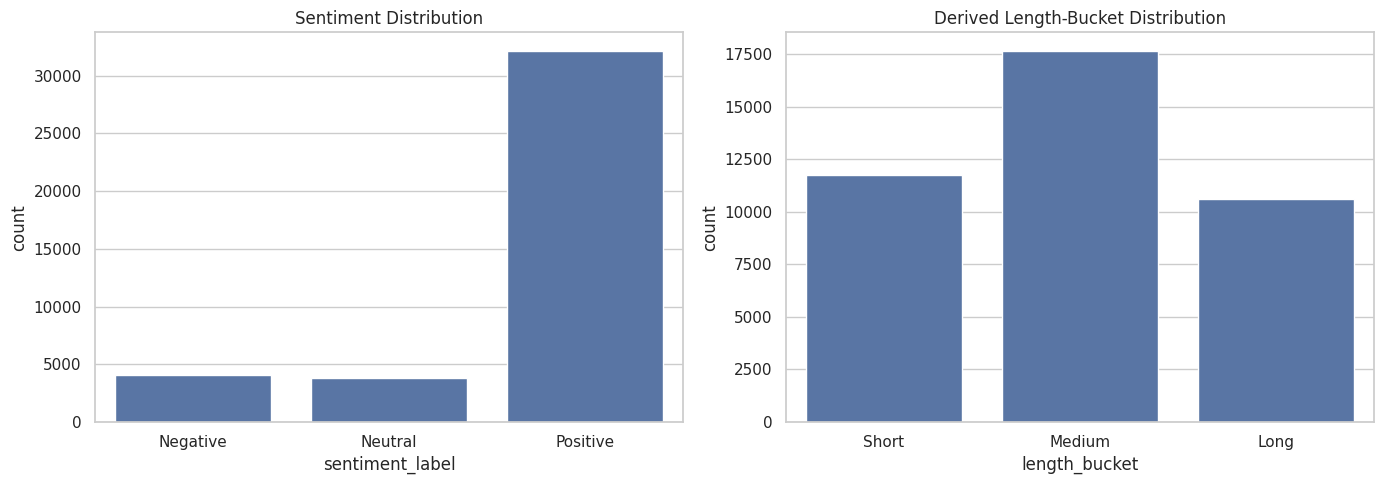

In [12]:
full_df = build_dataset_subset(DATA_DIR, CATEGORY_FILES, CONFIG.reviews_per_category, CONFIG.seed)
train_df, val_df, test_df = stratified_three_way_split(full_df, CONFIG.seed)

train_df.to_csv(RESULTS_DIR / "train_split_raw.csv", index=False)
val_df.to_csv(RESULTS_DIR / "val_split_raw.csv", index=False)
test_df.to_csv(RESULTS_DIR / "test_split_raw.csv", index=False)

summary_df = pd.concat(
    [
        split_summary(full_df, "full"),
        split_summary(train_df, "train"),
        split_summary(val_df, "validation"),
        split_summary(test_df, "test"),
    ],
    ignore_index=True,
)

category_counts = (
    full_df.groupby("category").size().reset_index(name="rows").sort_values("category").reset_index(drop=True)
)

print("Dataset sizes by split")
display(summary_df)
print("Category counts after sampling and deduplication")
display(category_counts)
print("Example reviews")
display(full_df[["category", "rating", "sentiment_label", "length_bucket", "review_text"]].head(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=full_df, x="sentiment_label", order=["Negative", "Neutral", "Positive"], ax=axes[0])
axes[0].set_title("Sentiment Distribution")
sns.countplot(data=full_df, x="length_bucket", order=["Short", "Medium", "Long"], ax=axes[1])
axes[1].set_title("Derived Length-Bucket Distribution")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "dataset_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
class Vocabulary:
    def __init__(self, specials: list[str]):
        self.specials = list(specials)
        self.token_to_id = {token: index for index, token in enumerate(self.specials)}
        self.id_to_token = list(self.specials)

    def build(self, token_sequences, min_freq: int = 1) -> None:
        token_counter = Counter()
        for sequence in token_sequences:
            token_counter.update(sequence)
        for token, frequency in token_counter.most_common():
            if frequency < min_freq:
                break
            if token not in self.token_to_id:
                self.token_to_id[token] = len(self.id_to_token)
                self.id_to_token.append(token)

    def encode(self, tokens: list[str]) -> list[int]:
        return [self.token_to_id.get(token, self.unk_idx) for token in tokens]

    def decode(self, token_ids: list[int], skip_special: bool = True) -> str:
        decoded_tokens = []
        special_tokens = set(self.specials)
        for token_id in token_ids:
            token = self.id_to_token[int(token_id)]
            if skip_special and token in special_tokens:
                continue
            decoded_tokens.append(token)
        decoded_text = " ".join(decoded_tokens)
        decoded_text = re.sub(r"\s+([.,!?;:])", r"\1", decoded_text).strip()
        return decoded_text

    @property
    def pad_idx(self) -> int:
        return self.token_to_id["<pad>"]

    @property
    def unk_idx(self) -> int:
        return self.token_to_id["<unk>"]

    @property
    def bos_idx(self) -> int:
        return self.token_to_id.get("<bos>", self.unk_idx)

    @property
    def eos_idx(self) -> int:
        return self.token_to_id.get("<eos>", self.unk_idx)

    def __len__(self) -> int:
        return len(self.id_to_token)


def encode_encoder_text(review_text: str, vocab: Vocabulary, max_len: int) -> tuple[list[int], list[int]]:
    tokens = ["<cls>"] + tokenize(review_text)[: max_len - 1]
    token_ids = vocab.encode(tokens)
    attention_mask = [1] * len(token_ids)
    if len(token_ids) < max_len:
        pad_length = max_len - len(token_ids)
        token_ids += [vocab.pad_idx] * pad_length
        attention_mask += [0] * pad_length
    return token_ids[:max_len], attention_mask[:max_len]


def encode_decoder_example(
    prompt_text: str,
    target_text: str,
    vocab: Vocabulary,
    max_len: int,
    max_target_len: int,
) -> tuple[list[int], list[int], list[int]]:
    prompt_tokens = tokenize(prompt_text)
    target_tokens = tokenize(target_text)[:max_target_len]
    max_prompt_tokens = max(1, max_len - len(target_tokens) - 3)
    prompt_tokens = prompt_tokens[:max_prompt_tokens]

    full_tokens = ["<bos>"] + prompt_tokens + ["<sep>"] + target_tokens + ["<eos>"]
    full_ids = vocab.encode(full_tokens)[: max_len + 1]
    if len(full_ids) < 2:
        full_ids = full_ids + [vocab.eos_idx]

    input_ids = full_ids[:-1]
    labels = full_ids[1:]
    prompt_prefix_length = min(len(prompt_tokens) + 2, len(labels))
    for index in range(max(0, prompt_prefix_length - 1)):
        labels[index] = -100

    attention_mask = [1] * len(input_ids)
    if len(input_ids) < max_len:
        pad_length = max_len - len(input_ids)
        input_ids += [vocab.pad_idx] * pad_length
        labels += [-100] * pad_length
        attention_mask += [0] * pad_length

    return input_ids[:max_len], labels[:max_len], attention_mask[:max_len]


class EncoderReviewDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, vocab: Vocabulary, max_len: int):
        self.review_ids = dataframe["review_id"].tolist()
        self.sentiment_ids = dataframe["sentiment_id"].tolist()
        self.length_ids = dataframe["length_id"].tolist()
        self.encoded_examples = [encode_encoder_text(text, vocab, max_len) for text in dataframe["review_text"].tolist()]

    def __len__(self) -> int:
        return len(self.review_ids)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        input_ids, attention_mask = self.encoded_examples[index]
        return {
            "review_id": torch.tensor(self.review_ids[index], dtype=torch.long),
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "sentiment_label": torch.tensor(self.sentiment_ids[index], dtype=torch.long),
            "length_label": torch.tensor(self.length_ids[index], dtype=torch.long),
        }


class DecoderExplanationDataset(Dataset):
    def __init__(
        self,
        prompts: list[str],
        targets: list[str],
        review_ids: list[int],
        vocab: Vocabulary,
        max_len: int,
        max_target_len: int,
    ):
        self.review_ids = review_ids
        self.encoded_examples = [
            encode_decoder_example(prompt, target, vocab, max_len, max_target_len)
            for prompt, target in zip(prompts, targets)
        ]

    def __len__(self) -> int:
        return len(self.review_ids)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        input_ids, labels, attention_mask = self.encoded_examples[index]
        return {
            "review_id": torch.tensor(self.review_ids[index], dtype=torch.long),
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        }


def multitask_collate(batch: list[dict[str, torch.Tensor]]) -> dict[str, torch.Tensor]:
    return {
        key: torch.stack([sample[key] for sample in batch])
        for key in ["review_id", "input_ids", "attention_mask", "sentiment_label", "length_label"]
    }


def decoder_collate(batch: list[dict[str, torch.Tensor]]) -> dict[str, torch.Tensor]:
    return {
        key: torch.stack([sample[key] for sample in batch])
        for key in ["review_id", "input_ids", "labels", "attention_mask"]
    }


def make_loader(dataset: Dataset, batch_size: int, shuffle: bool, collate_fn):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=PIN_MEMORY,
        collate_fn=collate_fn,
    )


encoder_vocab = Vocabulary(["<pad>", "<unk>", "<cls>"])
encoder_vocab.build(( ["<cls>"] + tokenize(text)[: CONFIG.encoder_max_len - 1] for text in train_df["review_text"].tolist() ), min_freq=CONFIG.min_freq)

print(f"Encoder vocabulary size: {len(encoder_vocab):,}")

Encoder vocabulary size: 15,271


## 10. Token Embedding and Positional Encoding
## 11. Scaled Dot-Product Attention from Scratch
## 12. Multi-Head Self-Attention from Scratch
## 13. Encoder Block with Residuals and Layer Normalization
## 14. Encoder-Only Transformer for Multi-Task Learning
## 15. Encoder Training Loop and Combined Loss
## 16. Encoder Evaluation, Metrics, and Learning Curves

The next code cells implement the complete encoder stack from scratch and train it jointly for:

- sentiment classification
- review length bucket prediction
- fixed-dimensional embedding extraction for downstream retrieval

In [14]:
class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, max_len: int, dropout: float, pad_idx: int):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
        token_vectors = self.token_embedding(input_ids)
        position_vectors = self.position_embedding(positions)
        return self.dropout(token_vectors + position_vectors)


class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout: float = 0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(query.size(-1))
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e4)
        attention_weights = torch.softmax(scores, dim=-1)
        if mask is not None:
            attention_weights = attention_weights * mask.float()
            attention_weights = attention_weights / attention_weights.sum(dim=-1, keepdim=True).clamp_min(1e-9)
        attention_weights = self.dropout(attention_weights)
        attended_values = torch.matmul(attention_weights, value)
        return attended_values, attention_weights


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.0, causal: bool = False):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.causal = causal
        self.query_projection = nn.Linear(d_model, d_model)
        self.key_projection = nn.Linear(d_model, d_model)
        self.value_projection = nn.Linear(d_model, d_model)
        self.output_projection = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention(dropout=dropout)
        self.output_dropout = nn.Dropout(dropout)

    def _build_mask(self, attention_mask: torch.Tensor | None, sequence_length: int, device: torch.device) -> torch.Tensor | None:
        combined_mask = None
        if attention_mask is not None:
            key_mask = attention_mask[:, None, None, :].bool()
            query_mask = attention_mask[:, None, :, None].bool()
            combined_mask = key_mask & query_mask
        if self.causal:
            causal_mask = torch.tril(torch.ones(sequence_length, sequence_length, device=device, dtype=torch.bool))
            causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
            combined_mask = causal_mask if combined_mask is None else (combined_mask & causal_mask)
        return combined_mask

    def forward(self, hidden_states: torch.Tensor, attention_mask: torch.Tensor | None = None) -> tuple[torch.Tensor, torch.Tensor]:
        batch_size, sequence_length, _ = hidden_states.size()
        query = self.query_projection(hidden_states).view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        key = self.key_projection(hidden_states).view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        value = self.value_projection(hidden_states).view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)

        mask = self._build_mask(attention_mask, sequence_length, hidden_states.device)
        attended_values, attention_weights = self.attention(query, key, value, mask=mask)
        attended_values = attended_values.transpose(1, 2).contiguous().view(batch_size, sequence_length, self.d_model)
        if attention_mask is not None:
            attended_values = attended_values * attention_mask.unsqueeze(-1).float()
        projected_output = self.output_projection(attended_values)
        return self.output_dropout(projected_output), attention_weights


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model: int, ff_multiplier: int, dropout: float):
        super().__init__()
        hidden_size = d_model * ff_multiplier
        self.network = nn.Sequential(
            nn.Linear(d_model, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        return self.network(hidden_states)


class EncoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_multiplier: int, dropout: float):
        super().__init__()
        self.attention_norm = nn.LayerNorm(d_model)
        self.feed_forward_norm = nn.LayerNorm(d_model)
        self.self_attention = MultiHeadSelfAttention(d_model, num_heads, dropout=dropout, causal=False)
        self.feed_forward = PositionwiseFeedForward(d_model, ff_multiplier, dropout)

    def forward(self, hidden_states: torch.Tensor, attention_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        attention_output, attention_weights = self.self_attention(self.attention_norm(hidden_states), attention_mask)
        hidden_states = hidden_states + attention_output
        hidden_states = hidden_states + self.feed_forward(self.feed_forward_norm(hidden_states))
        return hidden_states, attention_weights


class DecoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ff_multiplier: int, dropout: float):
        super().__init__()
        self.attention_norm = nn.LayerNorm(d_model)
        self.feed_forward_norm = nn.LayerNorm(d_model)
        self.self_attention = MultiHeadSelfAttention(d_model, num_heads, dropout=dropout, causal=True)
        self.feed_forward = PositionwiseFeedForward(d_model, ff_multiplier, dropout)

    def forward(self, hidden_states: torch.Tensor, attention_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        attention_output, attention_weights = self.self_attention(self.attention_norm(hidden_states), attention_mask)
        hidden_states = hidden_states + attention_output
        hidden_states = hidden_states + self.feed_forward(self.feed_forward_norm(hidden_states))
        return hidden_states, attention_weights


class ReviewEncoderTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_len: int,
        d_model: int,
        num_heads: int,
        num_layers: int,
        ff_multiplier: int,
        dropout: float,
        pad_idx: int,
        num_sentiment_labels: int,
        num_length_labels: int,
    ):
        super().__init__()
        self.embedding = TokenAndPositionEmbedding(vocab_size, d_model, max_len, dropout, pad_idx)
        self.layers = nn.ModuleList(
            [EncoderBlock(d_model, num_heads, ff_multiplier, dropout) for _ in range(num_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.sentiment_head = nn.Linear(d_model, num_sentiment_labels)
        self.length_head = nn.Linear(d_model, num_length_labels)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> dict[str, torch.Tensor]:
        hidden_states = self.embedding(input_ids)
        attention_maps = []
        for layer in self.layers:
            hidden_states, attention_weights = layer(hidden_states, attention_mask)
            attention_maps.append(attention_weights)
        hidden_states = self.final_norm(hidden_states)
        pooled_embedding = hidden_states[:, 0]
        return {
            "hidden_states": hidden_states,
            "embedding": pooled_embedding,
            "sentiment_logits": self.sentiment_head(pooled_embedding),
            "length_logits": self.length_head(pooled_embedding),
            "attention_maps": attention_maps,
        }


class DecoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_len: int,
        d_model: int,
        num_heads: int,
        num_layers: int,
        ff_multiplier: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.embedding = TokenAndPositionEmbedding(vocab_size, d_model, max_len, dropout, pad_idx)
        self.layers = nn.ModuleList(
            [DecoderBlock(d_model, num_heads, ff_multiplier, dropout) for _ in range(num_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embedding.token_embedding.weight

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> dict[str, torch.Tensor]:
        hidden_states = self.embedding(input_ids)
        attention_maps = []
        for layer in self.layers:
            hidden_states, attention_weights = layer(hidden_states, attention_mask)
            attention_maps.append(attention_weights)
        hidden_states = self.final_norm(hidden_states)
        logits = self.lm_head(hidden_states)
        return {"logits": logits, "attention_maps": attention_maps}

In [15]:
def move_batch_to_device(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    return {key: value.to(device) for key, value in batch.items()}


def clone_state_dict(model: nn.Module) -> dict[str, torch.Tensor]:
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def make_json_serializable(value):
    if isinstance(value, dict):
        return {str(key): make_json_serializable(item) for key, item in value.items()}
    if isinstance(value, list):
        return [make_json_serializable(item) for item in value]
    if isinstance(value, tuple):
        return [make_json_serializable(item) for item in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value


def save_json(payload: dict, path: Path) -> None:
    with path.open("w", encoding="utf-8") as handle:
        json.dump(make_json_serializable(payload), handle, indent=2)


encoder_criterion = nn.CrossEntropyLoss()
lm_criterion = nn.CrossEntropyLoss(ignore_index=-100, reduction="sum")


def run_encoder_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None = None,
) -> dict[str, float]:
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_examples = 0
    sentiment_predictions = []
    sentiment_targets = []
    length_predictions = []
    length_targets = []

    for batch in tqdm(loader, leave=False):
        batch = move_batch_to_device(batch, DEVICE)
        with torch.set_grad_enabled(is_training):
            outputs = model(batch["input_ids"], batch["attention_mask"])
            sentiment_loss = encoder_criterion(outputs["sentiment_logits"], batch["sentiment_label"])
            length_loss = encoder_criterion(outputs["length_logits"], batch["length_label"])
            loss = sentiment_loss + length_loss
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG.gradient_clip)
                optimizer.step()

        batch_size = batch["input_ids"].size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
        sentiment_predictions.extend(outputs["sentiment_logits"].argmax(dim=-1).detach().cpu().tolist())
        sentiment_targets.extend(batch["sentiment_label"].detach().cpu().tolist())
        length_predictions.extend(outputs["length_logits"].argmax(dim=-1).detach().cpu().tolist())
        length_targets.extend(batch["length_label"].detach().cpu().tolist())

    return {
        "loss": total_loss / max(total_examples, 1),
        "sentiment_accuracy": accuracy_score(sentiment_targets, sentiment_predictions),
        "length_accuracy": accuracy_score(length_targets, length_predictions),
        "sentiment_macro_f1": f1_score(sentiment_targets, sentiment_predictions, average="macro"),
        "length_macro_f1": f1_score(length_targets, length_predictions, average="macro"),
    }


def train_encoder_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader) -> pd.DataFrame:
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.encoder_lr, weight_decay=CONFIG.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)
    history_rows = []
    best_state = clone_state_dict(model)
    best_val_loss = float("inf")

    for epoch in range(1, CONFIG.encoder_epochs + 1):
        start_time = time.time()
        train_metrics = run_encoder_epoch(model, train_loader, optimizer=optimizer)
        val_metrics = run_encoder_epoch(model, val_loader, optimizer=None)
        scheduler.step(val_metrics["loss"])

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_sentiment_accuracy": train_metrics["sentiment_accuracy"],
            "val_sentiment_accuracy": val_metrics["sentiment_accuracy"],
            "train_length_accuracy": train_metrics["length_accuracy"],
            "val_length_accuracy": val_metrics["length_accuracy"],
            "train_sentiment_macro_f1": train_metrics["sentiment_macro_f1"],
            "val_sentiment_macro_f1": val_metrics["sentiment_macro_f1"],
            "train_length_macro_f1": train_metrics["length_macro_f1"],
            "val_length_macro_f1": val_metrics["length_macro_f1"],
            "learning_rate": optimizer.param_groups[0]["lr"],
            "epoch_seconds": time.time() - start_time,
        }
        history_rows.append(row)
        print(
            f"Encoder epoch {epoch:02d} | "
            f"train loss {row['train_loss']:.4f} | val loss {row['val_loss']:.4f} | "
            f"val sentiment acc {row['val_sentiment_accuracy']:.4f} | val length acc {row['val_length_accuracy']:.4f}"
        )
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = clone_state_dict(model)

    model.load_state_dict(best_state)
    return pd.DataFrame(history_rows)


@torch.no_grad()
def collect_encoder_outputs(model: nn.Module, loader: DataLoader) -> dict[str, np.ndarray]:
    model.eval()
    review_ids = []
    sentiment_targets = []
    length_targets = []
    sentiment_predictions = []
    length_predictions = []
    embeddings = []

    for batch in tqdm(loader, leave=False):
        batch = move_batch_to_device(batch, DEVICE)
        outputs = model(batch["input_ids"], batch["attention_mask"])
        review_ids.extend(batch["review_id"].cpu().tolist())
        sentiment_targets.extend(batch["sentiment_label"].cpu().tolist())
        length_targets.extend(batch["length_label"].cpu().tolist())
        sentiment_predictions.extend(outputs["sentiment_logits"].argmax(dim=-1).cpu().tolist())
        length_predictions.extend(outputs["length_logits"].argmax(dim=-1).cpu().tolist())
        embeddings.append(outputs["embedding"].cpu().numpy())

    return {
        "review_ids": np.array(review_ids),
        "sentiment_targets": np.array(sentiment_targets),
        "length_targets": np.array(length_targets),
        "sentiment_predictions": np.array(sentiment_predictions),
        "length_predictions": np.array(length_predictions),
        "embeddings": np.concatenate(embeddings, axis=0),
    }


def attach_encoder_predictions(dataframe: pd.DataFrame, outputs: dict[str, np.ndarray]) -> pd.DataFrame:
    indexed_df = dataframe.set_index("review_id").copy()
    indexed_df["pred_sentiment_id"] = outputs["sentiment_predictions"]
    indexed_df["pred_length_id"] = outputs["length_predictions"]
    indexed_df["pred_sentiment"] = indexed_df["pred_sentiment_id"].map(ID_TO_SENTIMENT)
    indexed_df["pred_length_bucket"] = indexed_df["pred_length_id"].map(ID_TO_LENGTH)
    indexed_df["embedding_row"] = np.arange(len(indexed_df))
    return indexed_df.reset_index()


def build_classification_table(y_true: np.ndarray, y_pred: np.ndarray, label_names: list[str]) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(label_names))),
        target_names=label_names,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).transpose().round(4)


def plot_encoder_history(history_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation")
    axes[0].set_title("Encoder Combined Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_sentiment_accuracy"], marker="o", label="train sentiment")
    axes[1].plot(history_df["epoch"], history_df["val_sentiment_accuracy"], marker="o", label="validation sentiment")
    axes[1].set_title("Sentiment Accuracy")
    axes[1].legend()

    axes[2].plot(history_df["epoch"], history_df["train_length_accuracy"], marker="o", label="train length")
    axes[2].plot(history_df["epoch"], history_df["val_length_accuracy"], marker="o", label="validation length")
    axes[2].set_title("Length-Bucket Accuracy")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "encoder_learning_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


def run_language_model_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None = None,
) -> dict[str, float]:
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_tokens = 0
    for batch in tqdm(loader, leave=False):
        batch = move_batch_to_device(batch, DEVICE)
        with torch.set_grad_enabled(is_training):
            outputs = model(batch["input_ids"], batch["attention_mask"])
            loss_sum = lm_criterion(outputs["logits"].reshape(-1, outputs["logits"].size(-1)), batch["labels"].reshape(-1))
            target_tokens = (batch["labels"] != -100).sum().item()
            normalized_loss = loss_sum / max(target_tokens, 1)
            if is_training:
                optimizer.zero_grad()
                normalized_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG.gradient_clip)
                optimizer.step()

        total_loss += loss_sum.item()
        total_tokens += target_tokens

    mean_loss = total_loss / max(total_tokens, 1)
    return {"loss": mean_loss, "perplexity": math.exp(min(mean_loss, 20))}


def train_language_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, learning_rate: float) -> pd.DataFrame:
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=CONFIG.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)
    best_state = clone_state_dict(model)
    best_val_loss = float("inf")
    history_rows = []

    for epoch in range(1, CONFIG.decoder_epochs + 1):
        start_time = time.time()
        train_metrics = run_language_model_epoch(model, train_loader, optimizer=optimizer)
        val_metrics = run_language_model_epoch(model, val_loader, optimizer=None)
        scheduler.step(val_metrics["loss"])
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_perplexity": train_metrics["perplexity"],
            "val_perplexity": val_metrics["perplexity"],
            "learning_rate": optimizer.param_groups[0]["lr"],
            "epoch_seconds": time.time() - start_time,
        }
        history_rows.append(row)
        print(
            f"Decoder epoch {epoch:02d} | train ppl {row['train_perplexity']:.4f} | "
            f"val ppl {row['val_perplexity']:.4f}"
        )
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = clone_state_dict(model)

    model.load_state_dict(best_state)
    return pd.DataFrame(history_rows)


def plot_decoder_history(history_df: pd.DataFrame, title_prefix: str, output_name: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation")
    axes[0].set_title(f"{title_prefix} Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_perplexity"], marker="o", label="train")
    axes[1].plot(history_df["epoch"], history_df["val_perplexity"], marker="o", label="validation")
    axes[1].set_title(f"{title_prefix} Perplexity")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / output_name, dpi=150, bbox_inches="tight")
    plt.show()

  0%|          | 0/438 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Encoder epoch 01 | train loss 0.6455 | val loss 0.5646 | val sentiment acc 0.8096 | val length acc 1.0000


  0%|          | 0/438 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

...

Encoder epoch 03 | train loss 0.4589 | val loss 0.4683 | val sentiment acc 0.8276 | val length acc 1.0000


  0%|          | 0/438 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Encoder epoch 04 | train loss 0.4229 | val loss 0.4769 | val sentiment acc 0.8291 | val length acc 1.0000


,epoch,train_loss,val_loss,train_sentiment_accuracy,val_sentiment_accuracy,train_length_accuracy,val_length_accuracy,train_sentiment_macro_f1,val_sentiment_macro_f1,train_length_macro_f1,val_length_macro_f1,learning_rate,epoch_seconds
0,1,0.645475,0.564587,0.804186,0.809635,0.973032,1.0,0.345113,0.346853,0.973142,1.0,0.0003,57.042102
1,2,0.507163,0.485476,0.815331,0.822804,0.999857,1.0,0.445704,0.488233,0.999856,1.0,0.0003,58.454761
2,3,0.458876,0.468283,0.831869,0.827638,0.999893,1.0,0.520311,0.519775,0.999892,1.0,0.0003,59.958475
3,4,0.422893,0.476929,0.839727,0.829138,0.999821,1.0,0.561629,0.548785,0.999827,1.0,0.0003,59.773225


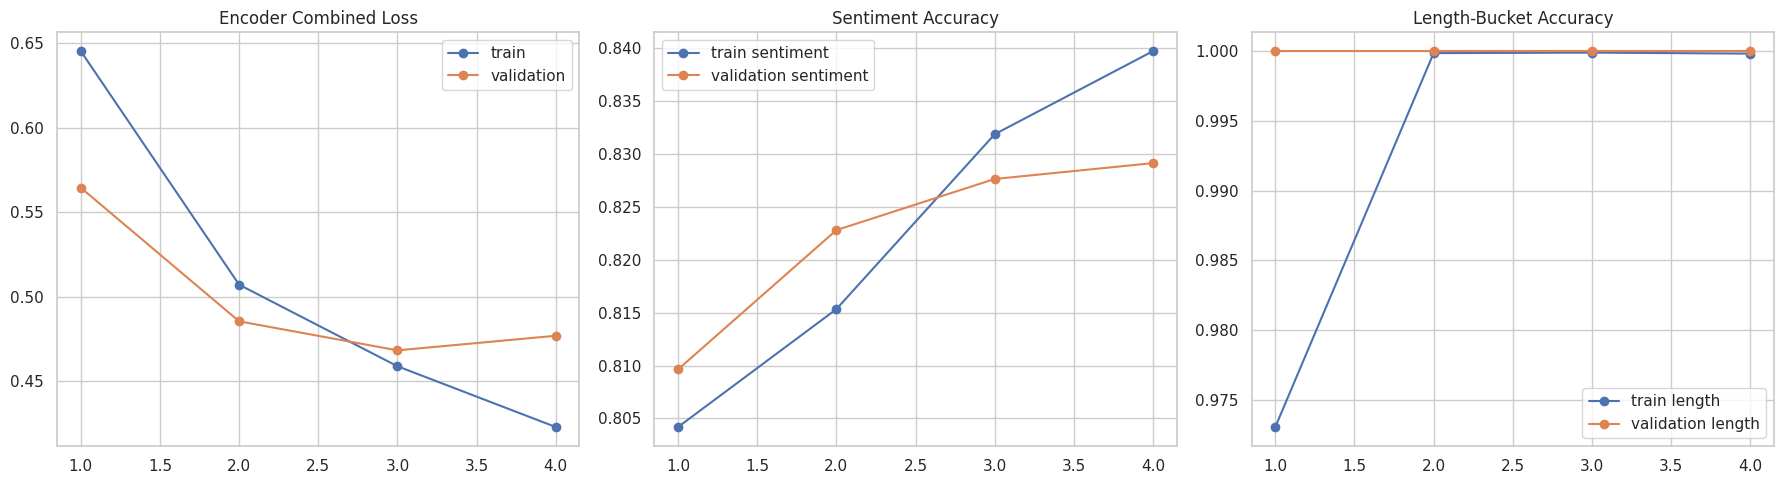

In [16]:
train_encoder_dataset = EncoderReviewDataset(train_df, encoder_vocab, CONFIG.encoder_max_len)
val_encoder_dataset = EncoderReviewDataset(val_df, encoder_vocab, CONFIG.encoder_max_len)
test_encoder_dataset = EncoderReviewDataset(test_df, encoder_vocab, CONFIG.encoder_max_len)

train_encoder_loader = make_loader(train_encoder_dataset, CONFIG.encoder_batch_size, True, multitask_collate)
val_encoder_loader = make_loader(val_encoder_dataset, CONFIG.encoder_batch_size, False, multitask_collate)
test_encoder_loader = make_loader(test_encoder_dataset, CONFIG.encoder_batch_size, False, multitask_collate)

encoder_model = ReviewEncoderTransformer(
    vocab_size=len(encoder_vocab),
    max_len=CONFIG.encoder_max_len,
    d_model=CONFIG.d_model,
    num_heads=CONFIG.num_heads,
    num_layers=CONFIG.num_layers,
    ff_multiplier=CONFIG.ff_multiplier,
    dropout=CONFIG.dropout,
    pad_idx=encoder_vocab.pad_idx,
    num_sentiment_labels=len(SENTIMENT_TO_ID),
    num_length_labels=len(LENGTH_TO_ID),
).to(DEVICE)

encoder_history = train_encoder_model(encoder_model, train_encoder_loader, val_encoder_loader)
display(encoder_history)
plot_encoder_history(encoder_history)

encoder_checkpoint = {
    "config": asdict(CONFIG),
    "encoder_vocab": encoder_vocab.id_to_token,
    "state_dict": encoder_model.state_dict(),
}
torch.save(encoder_checkpoint, MODELS_DIR / "encoder_multitask_transformer.pt")
encoder_history.to_csv(RESULTS_DIR / "encoder_history.csv", index=False)

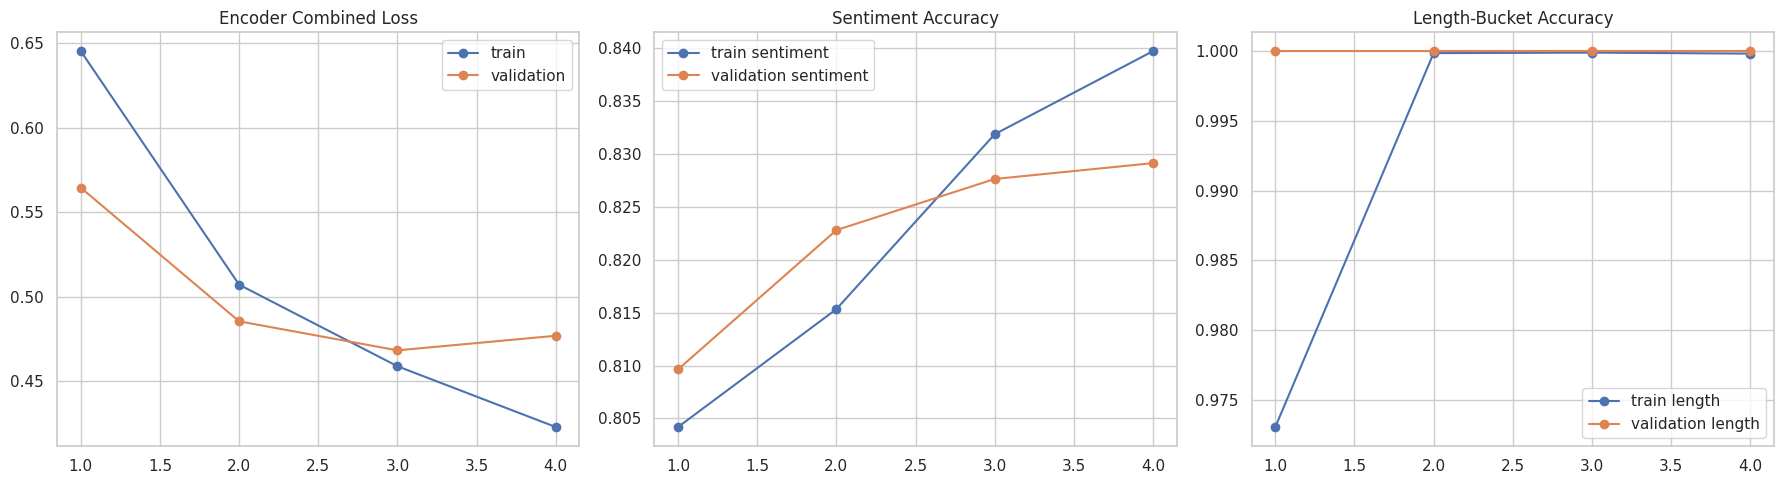

  0%|          | 0/438 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Test sentiment classification report


,precision,recall,f1-score,support
Negative,0.5645,0.3230,0.4108,610.0000
Neutral,0.4365,0.1396,0.2115,566.0000
Positive,0.8550,0.9695,0.9087,4824.0000
accuracy,0.8255,0.8255,0.8255,0.8255
macro avg,0.6187,0.4774,0.5103,6000.0000
weighted avg,0.7860,0.8255,0.7923,6000.0000


Test length-bucket classification report


,precision,recall,f1-score,support
Short,1.0,1.0,1.0,1765.0
Medium,1.0,1.0,1.0,2615.0
Long,1.0,1.0,1.0,1620.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,6000.0
weighted avg,1.0,1.0,1.0,6000.0


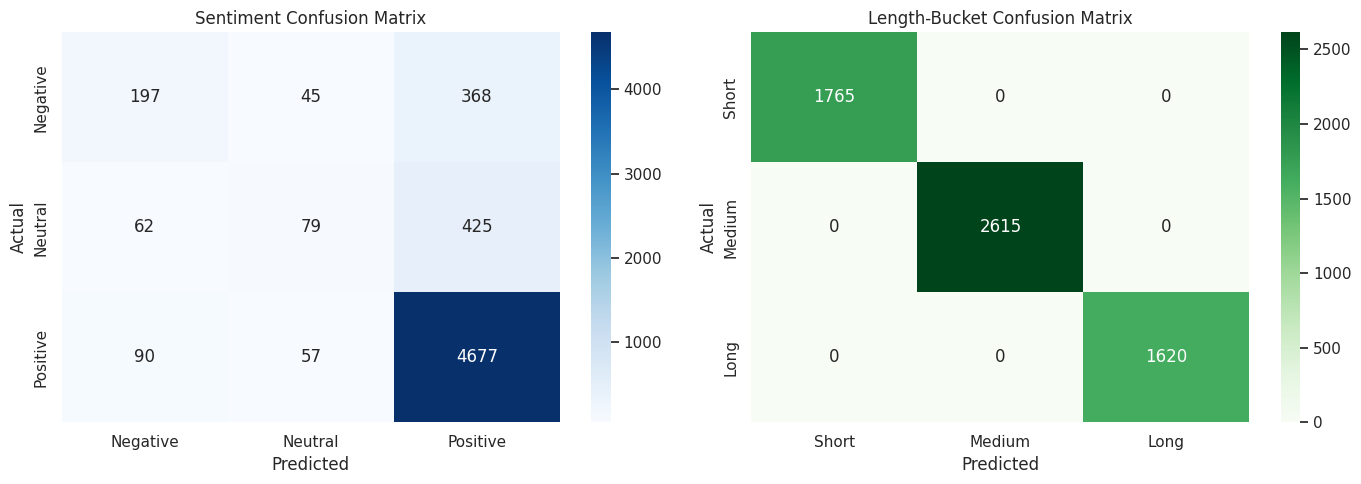

In [17]:
plot_encoder_history(encoder_history)

train_encoder_eval_loader = make_loader(train_encoder_dataset, CONFIG.encoder_batch_size, False, multitask_collate)
val_encoder_eval_loader = make_loader(val_encoder_dataset, CONFIG.encoder_batch_size, False, multitask_collate)
test_encoder_eval_loader = make_loader(test_encoder_dataset, CONFIG.encoder_batch_size, False, multitask_collate)

train_outputs = collect_encoder_outputs(encoder_model, train_encoder_eval_loader)
val_outputs = collect_encoder_outputs(encoder_model, val_encoder_eval_loader)
test_outputs = collect_encoder_outputs(encoder_model, test_encoder_eval_loader)

train_df_pred = attach_encoder_predictions(train_df, train_outputs)
val_df_pred = attach_encoder_predictions(val_df, val_outputs)
test_df_pred = attach_encoder_predictions(test_df, test_outputs)

sentiment_labels = ["Negative", "Neutral", "Positive"]
length_labels = ["Short", "Medium", "Long"]

sentiment_report = build_classification_table(test_outputs["sentiment_targets"], test_outputs["sentiment_predictions"], sentiment_labels)
length_report = build_classification_table(test_outputs["length_targets"], test_outputs["length_predictions"], length_labels)

print("Test sentiment classification report")
display(sentiment_report)
print("Test length-bucket classification report")
display(length_report)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    confusion_matrix(test_outputs["sentiment_targets"], test_outputs["sentiment_predictions"], labels=[0, 1, 2]),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sentiment_labels,
    yticklabels=sentiment_labels,
    ax=axes[0],
)
axes[0].set_title("Sentiment Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(test_outputs["length_targets"], test_outputs["length_predictions"], labels=[0, 1, 2]),
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=length_labels,
    yticklabels=length_labels,
    ax=axes[1],
)
axes[1].set_title("Length-Bucket Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "encoder_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

np.savez_compressed(
    RESULTS_DIR / "train_embeddings.npz",
    embeddings=train_outputs["embeddings"],
    review_ids=train_outputs["review_ids"],
    sentiment_ids=train_outputs["sentiment_predictions"],
    length_ids=train_outputs["length_predictions"],
)
np.savez_compressed(
    RESULTS_DIR / "val_embeddings.npz",
    embeddings=val_outputs["embeddings"],
    review_ids=val_outputs["review_ids"],
)
np.savez_compressed(
    RESULTS_DIR / "test_embeddings.npz",
    embeddings=test_outputs["embeddings"],
    review_ids=test_outputs["review_ids"],
)

train_df_pred.to_csv(RESULTS_DIR / "train_split_with_predictions.csv", index=False)
val_df_pred.to_csv(RESULTS_DIR / "val_split_with_predictions.csv", index=False)
test_df_pred.to_csv(RESULTS_DIR / "test_split_with_predictions.csv", index=False)

encoder_metrics = {
    "sentiment_report": sentiment_report.to_dict(),
    "length_report": length_report.to_dict(),
    "test_sentiment_accuracy": accuracy_score(test_outputs["sentiment_targets"], test_outputs["sentiment_predictions"]),
    "test_length_accuracy": accuracy_score(test_outputs["length_targets"], test_outputs["length_predictions"]),
}
save_json(encoder_metrics, RESULTS_DIR / "encoder_metrics.json")

## 17. Review Embedding Extraction and Saving
## 18. Training Embedding Index and Similarity Retrieval
## 19. Retrieval Quality Inspection and Top-k Analysis
## 20. RAG Input Template and Explanation Target Construction

The encoder predictions and embeddings above are now used to build the retrieval layer. The next cell:

- normalizes the learned review embeddings
- performs cosine-similarity top-k search over the training corpus
- inspects retrieval quality with concrete query/retrieval examples
- constructs the structured decoder prompt template for both the full RAG model and the no-retrieval baseline

In [18]:
def l2_normalize(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.clip(norms, a_min=1e-12, a_max=None)
    return matrix / norms


@torch.no_grad()
def batched_cosine_topk(
    query_embeddings: np.ndarray,
    index_embeddings: np.ndarray,
    top_k: int,
    chunk_size: int = 512,
    exclude_self: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    query_tensor = torch.tensor(query_embeddings, dtype=torch.float32, device=DEVICE)
    index_tensor = torch.tensor(index_embeddings, dtype=torch.float32, device=DEVICE)
    top_indices = []
    top_scores = []

    for start in tqdm(range(0, len(query_tensor), chunk_size), desc="Retrieving", leave=False):
        stop = min(start + chunk_size, len(query_tensor))
        batch_queries = query_tensor[start:stop]
        similarity = batch_queries @ index_tensor.T
        if exclude_self and len(query_embeddings) == len(index_embeddings):
            row_offsets = torch.arange(stop - start, device=DEVICE)
            similarity[row_offsets, torch.arange(start, stop, device=DEVICE)] = -1e9
        scores, indices = torch.topk(similarity, k=top_k, dim=-1)
        top_indices.append(indices.cpu().numpy())
        top_scores.append(scores.cpu().numpy())

    return np.vstack(top_indices), np.vstack(top_scores)


def build_retrieval_examples(
    query_df: pd.DataFrame,
    retrieved_indices: np.ndarray,
    retrieved_scores: np.ndarray,
    train_reference_df: pd.DataFrame,
    sample_size: int = 5,
) -> pd.DataFrame:
    rng = np.random.default_rng(CONFIG.seed)
    chosen_rows = rng.choice(len(query_df), size=min(sample_size, len(query_df)), replace=False)
    rows = []
    for query_position in chosen_rows:
        query_row = query_df.iloc[query_position]
        for rank, (candidate_index, score) in enumerate(
            zip(retrieved_indices[query_position], retrieved_scores[query_position]),
            start=1,
        ):
            candidate_row = train_reference_df.iloc[int(candidate_index)]
            rows.append(
                {
                    "query_review_id": int(query_row["review_id"]),
                    "query_sentiment": query_row["pred_sentiment"],
                    "rank": rank,
                    "similarity": round(float(score), 4),
                    "query_review": query_row["review_text"],
                    "retrieved_review": candidate_row["review_text"],
                    "retrieved_sentiment": candidate_row["pred_sentiment"],
                    "retrieved_category": candidate_row["category"],
                }
            )
    return pd.DataFrame(rows)


def build_rag_prompt(review_text: str, sentiment_label: str, length_bucket: str, retrieved_reviews: list[str]) -> str:
    prompt_parts = [
        "<review>",
        shorten_text(review_text, CONFIG.review_context_words),
        "<sentiment>",
        sentiment_label.lower(),
        "<length>",
        length_bucket.lower(),
    ]
    if retrieved_reviews:
        prompt_parts.append("<retrieved>")
        for index, retrieved_review in enumerate(retrieved_reviews, start=1):
            prompt_parts.append(f"<r{index}>")
            prompt_parts.append(shorten_text(retrieved_review, CONFIG.retrieved_context_words))
    prompt_parts.append("<explanation>")
    return " ".join(prompt_parts)


def build_decoder_frame(
    dataframe: pd.DataFrame,
    retrieved_indices: np.ndarray,
    train_reference_df: pd.DataFrame,
) -> pd.DataFrame:
    train_review_texts = train_reference_df["review_text"].tolist()
    rows = []
    iterator = zip(dataframe.itertuples(index=False), retrieved_indices)
    for row, candidate_indices in tqdm(iterator, total=len(dataframe), desc="Building decoder prompts", leave=False):
        retrieved_reviews = [train_review_texts[int(candidate_index)] for candidate_index in candidate_indices]
        prompt_with_retrieval = build_rag_prompt(
            row.review_text,
            row.pred_sentiment,
            row.pred_length_bucket,
            retrieved_reviews,
        )
        prompt_without_retrieval = build_rag_prompt(
            row.review_text,
            row.pred_sentiment,
            row.pred_length_bucket,
            [],
        )
        target_text = build_reference_explanation(row.review_text, row.pred_sentiment, row.pred_length_bucket)
        rows.append(
            {
                "review_id": row.review_id,
                "prompt_with_retrieval": prompt_with_retrieval,
                "prompt_without_retrieval": prompt_without_retrieval,
                "target_text": target_text,
            }
        )
    return pd.DataFrame(rows)


train_norm_embeddings = l2_normalize(train_outputs["embeddings"])
val_norm_embeddings = l2_normalize(val_outputs["embeddings"])
test_norm_embeddings = l2_normalize(test_outputs["embeddings"])

train_retrieved_idx, train_retrieved_scores = batched_cosine_topk(
    train_norm_embeddings,
    train_norm_embeddings,
    top_k=CONFIG.top_k,
    chunk_size=CONFIG.retrieval_chunk_size,
    exclude_self=True,
)
val_retrieved_idx, val_retrieved_scores = batched_cosine_topk(
    val_norm_embeddings,
    train_norm_embeddings,
    top_k=CONFIG.top_k,
    chunk_size=CONFIG.retrieval_chunk_size,
    exclude_self=False,
)
test_retrieved_idx, test_retrieved_scores = batched_cosine_topk(
    test_norm_embeddings,
    train_norm_embeddings,
    top_k=CONFIG.top_k,
    chunk_size=CONFIG.retrieval_chunk_size,
    exclude_self=False,
)

retrieval_examples_df = build_retrieval_examples(test_df_pred, test_retrieved_idx, test_retrieved_scores, train_df_pred, sample_size=5)
retrieval_examples_df.to_csv(RESULTS_DIR / "retrieval_examples.csv", index=False)
display(retrieval_examples_df)

k_analysis_rows = []
train_pred_sentiment_ids = train_df_pred["pred_sentiment_id"].to_numpy()
for k_value in [1, 3, 5]:
    test_indices_k, _ = batched_cosine_topk(
        test_norm_embeddings,
        train_norm_embeddings,
        top_k=k_value,
        chunk_size=CONFIG.retrieval_chunk_size,
        exclude_self=False,
    )
    retrieved_sentiments = train_pred_sentiment_ids[test_indices_k]
    same_sentiment_rate = (retrieved_sentiments == test_df_pred["pred_sentiment_id"].to_numpy()[:, None]).mean()
    unique_category_counts = [len(set(train_df_pred.iloc[row_indices]["category"].tolist())) for row_indices in test_indices_k]
    k_analysis_rows.append(
        {
            "k": k_value,
            "same_predicted_sentiment_rate": round(float(same_sentiment_rate), 4),
            "average_unique_categories": round(float(np.mean(unique_category_counts)), 4),
        }
    )

retrieval_k_analysis = pd.DataFrame(k_analysis_rows)
retrieval_k_analysis.to_csv(RESULTS_DIR / "retrieval_topk_analysis.csv", index=False)
print("Top-k retrieval analysis")
display(retrieval_k_analysis)

train_decoder_df = build_decoder_frame(train_df_pred, train_retrieved_idx, train_df_pred)
val_decoder_df = build_decoder_frame(val_df_pred, val_retrieved_idx, train_df_pred)
test_decoder_df = build_decoder_frame(test_df_pred, test_retrieved_idx, train_df_pred)

train_decoder_df.to_csv(RESULTS_DIR / "train_decoder_inputs.csv", index=False)
val_decoder_df.to_csv(RESULTS_DIR / "val_decoder_inputs.csv", index=False)
test_decoder_df.to_csv(RESULTS_DIR / "test_decoder_inputs.csv", index=False)

display(test_decoder_df.head(3))

Retrieving:   0%|          | 0/55 [00:00<?, ?it/s]

Retrieving:   0%|          | 0/12 [00:00<?, ?it/s]

Retrieving:   0%|          | 0/12 [00:00<?, ?it/s]

,query_review_id,query_sentiment,rank,similarity,query_review,retrieved_review,retrieved_sentiment,retrieved_category
0,11011,Positive,1,0.9835,Great! It did its job....of course these dont last forever....but 2-3 months was great for me! (I am hard on my phones as well...),"I'm usually a pressed powder girl, but wanted to try something other than a liquid foundation...well this was great! It goes on so smoothly and covers wonderfully. Feels like a...",Positive,beauty
1,11011,Positive,2,0.9826,Great! It did its job....of course these dont last forever....but 2-3 months was great for me! (I am hard on my phones as well...),"The perfect little glasses for serving wine. I have long loved the little glasses used to serve wine and cider (sidra) in Spain, but have found that they are in general very ov...",Positive,home
2,11011,Positive,3,0.9825,Great! It did its job....of course these dont last forever....but 2-3 months was great for me! (I am hard on my phones as well...),"Great stuff as described, made my nails more flexible and stronger. I have really bad peeling nailand this seems to help. I get the occasional peel in my nail but not as bad as...",Positive,beauty
3,14479,Positive,1,0.9894,"I purchased this to protect my Samsung S3 (i747) from AT&T.; I received it today and immediately put it on the phone. While overall fit and feel is very good, the cutout at the...",I bought this remote to use with my G-Box Midnight MX2.Setup was a breeze. Simply plug in the USB transmitter and you're all set. (It does take up one USB port on the device).T...,Positive,electronics
4,14479,Positive,2,0.9891,"I purchased this to protect my Samsung S3 (i747) from AT&T.; I received it today and immediately put it on the phone. While overall fit and feel is very good, the cutout at the...","Update 3/5/2010:There *is* a little lag, but nothing like what I had on my old blue tooth when I am listening to the navigation commands on my phone, and so little that I hadn'...",Positive,cellphones
5,14479,Positive,3,0.9890,"I purchased this to protect my Samsung S3 (i747) from AT&T.; I received it today and immediately put it on the phone. While overall fit and feel is very good, the cutout at the...","You only need to use a tiny bit, which makes it less expensive than you might initially think. Spray is a little hard to control - the sprayer on mine is different from that pi...",Positive,beauty
6,978,Positive,1,0.9906,"So, I decided to try this on my very cracked heels. I don't like to put oil on my face, so I thought, hmmmmmm,let's give it a go on the feet. The oil itself is very nice and si...","This was just delivered a few days back and so far I'm really impressed. It's turned my Droid Bionic into a multi-media machine, it was simple to assemble (all you do is put th...",Positive,cellphones
7,978,Positive,2,0.9891,"So, I decided to try this on my very cracked heels. I don't like to put oil on my face, so I thought, hmmmmmm,let's give it a go on the feet. The oil itself is very nice and si...","So far it's been great. I originally wanted the Stainless Steel one, but decided to try out this version first because of price and availability. At the date of my purchase thi...",Positive,home
8,978,Positive,3,0.9889,"So, I decided to try this on my very cracked heels. I don't like to put oil on my face, so I thought, hmmmmmm,let's give it a go on the feet. The oil itself is very nice and si...","This is a great looking rechargeable battery and case for the iphone4. It is well made and fits securely over the iphone4. I have not run it down completely yet, but the manufa...",Positive,cellphones
9,32833,Positive,1,0.9884,"I haven't used it to heat anything up yet, but did try it out and my initial impression is that this will be a great stove! It's small, starts easily on 1 push and is nicely ad...","This is the third brand of lotion I've tried on my quest for a body lotion and it's a keeper. I love the consistency; not too thick without feeling like water, and the

Retrieving:   0%|          | 0/12 [00:00<?, ?it/s]

...

,k,same_predicted_sentiment_rate,average_unique_categories
0,1,0.9805,1.0000
1,3,0.9783,2.4093
2,5,0.9765,3.3007


Building decoder prompts:   0%|          | 0/27996 [00:00<?, ?it/s]

Building decoder prompts:   0%|          | 0/5999 [00:00<?, ?it/s]

Building decoder prompts:   0%|          | 0/6000 [00:00<?, ?it/s]

,review_id,prompt_with_retrieval,prompt_without_retrieval,target_text
0,27665,<review> i purchased this blade as i have to make a lot of things from scratch due to our special diet issues . when i first started using my kitchen aid i thought wouldn't it ...,<review> i purchased this blade as i have to make a lot of things from scratch due to our special diet issues . when i first started using my kitchen aid i thought wouldn't it ...,"This review is positive because it mentions blade and thought, suggesting overall satisfaction and a favorable product experience. The review provides a moderate amount of deta..."
1,2044,"<review> i love turbie twists . they are my go to every day . i use them after the shower , or at night when i want to keep my hair from getting wet when i wash my face i'm a s...","<review> i love turbie twists . they are my go to every day . i use them after the shower , or at night when i want to keep my hair from getting wet when i wash my face i'm a s...","This review is positive because it mentions love and turbie, suggesting overall satisfaction and a favorable product experience. The review provides a moderate amount of detail..."
2,5049,"<review> once i figured out how to open it so that the pump was active , which was easier than i was making it out to be , it worked great . i put my polish remover in it and i...","<review> once i figured out how to open it so that the pump was active , which was easier than i was making it out to be , it worked great . i put my polish remover in it and i...","This review is positive because it mentions once and figured, suggesting overall satisfaction and a favorable product experience. The review provides a moderate amount of detai..."


## 21. Causal Masked Self-Attention from Scratch
## 22. Decoder Block and Decoder-Only Transformer
## 23. Decoder Training Loop and Language Modeling Loss
## 24. Autoregressive Explanation Generation
## 25. Perplexity Evaluation and Generated Sample Analysis
## 26. No-Retrieval Baseline and RAG Ablation Study
## 27. Model Checkpointing and Results Export

The decoder architecture reuses the same scratch-built components, but now enables **causal masking** so each position can only attend to current and earlier tokens. Two decoder runs are trained below:

- a full **RAG** decoder that consumes retrieved reviews in the prompt
- a **baseline** decoder with the same architecture but without retrieved context

In [19]:
decoder_vocab = Vocabulary(["<pad>", "<unk>", "<bos>", "<eos>", "<sep>"])
decoder_training_texts = (
    train_decoder_df["prompt_with_retrieval"].tolist()
    + train_decoder_df["prompt_without_retrieval"].tolist()
    + train_decoder_df["target_text"].tolist()
)
decoder_vocab.build((tokenize(text) for text in decoder_training_texts), min_freq=CONFIG.min_freq)

print(f"Decoder vocabulary size: {len(decoder_vocab):,}")

train_rag_dataset = DecoderExplanationDataset(
    prompts=train_decoder_df["prompt_with_retrieval"].tolist(),
    targets=train_decoder_df["target_text"].tolist(),
    review_ids=train_decoder_df["review_id"].tolist(),
    vocab=decoder_vocab,
    max_len=CONFIG.decoder_max_len,
    max_target_len=CONFIG.max_generation_len,
)
val_rag_dataset = DecoderExplanationDataset(
    prompts=val_decoder_df["prompt_with_retrieval"].tolist(),
    targets=val_decoder_df["target_text"].tolist(),
    review_ids=val_decoder_df["review_id"].tolist(),
    vocab=decoder_vocab,
    max_len=CONFIG.decoder_max_len,
    max_target_len=CONFIG.max_generation_len,
)
test_rag_dataset = DecoderExplanationDataset(
    prompts=test_decoder_df["prompt_with_retrieval"].tolist(),
    targets=test_decoder_df["target_text"].tolist(),
    review_ids=test_decoder_df["review_id"].tolist(),
    vocab=decoder_vocab,
    max_len=CONFIG.decoder_max_len,
    max_target_len=CONFIG.max_generation_len,
)

train_baseline_dataset = DecoderExplanationDataset(
    prompts=train_decoder_df["prompt_without_retrieval"].tolist(),
    targets=train_decoder_df["target_text"].tolist(),
    review_ids=train_decoder_df["review_id"].tolist(),
    vocab=decoder_vocab,
    max_len=CONFIG.decoder_max_len,
    max_target_len=CONFIG.max_generation_len,
)
val_baseline_dataset = DecoderExplanationDataset(
    prompts=val_decoder_df["prompt_without_retrieval"].tolist(),
    targets=val_decoder_df["target_text"].tolist(),
    review_ids=val_decoder_df["review_id"].tolist(),
    vocab=decoder_vocab,
    max_len=CONFIG.decoder_max_len,
    max_target_len=CONFIG.max_generation_len,
)
test_baseline_dataset = DecoderExplanationDataset(
    prompts=test_decoder_df["prompt_without_retrieval"].tolist(),
    targets=test_decoder_df["target_text"].tolist(),
    review_ids=test_decoder_df["review_id"].tolist(),
    vocab=decoder_vocab,
    max_len=CONFIG.decoder_max_len,
    max_target_len=CONFIG.max_generation_len,
)

train_rag_loader = make_loader(train_rag_dataset, CONFIG.decoder_batch_size, True, decoder_collate)
val_rag_loader = make_loader(val_rag_dataset, CONFIG.decoder_batch_size, False, decoder_collate)
test_rag_loader = make_loader(test_rag_dataset, CONFIG.decoder_batch_size, False, decoder_collate)

train_baseline_loader = make_loader(train_baseline_dataset, CONFIG.decoder_batch_size, True, decoder_collate)
val_baseline_loader = make_loader(val_baseline_dataset, CONFIG.decoder_batch_size, False, decoder_collate)
test_baseline_loader = make_loader(test_baseline_dataset, CONFIG.decoder_batch_size, False, decoder_collate)

Decoder vocabulary size: 24,441


  0%|          | 0/875 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Decoder epoch 01 | train ppl 21.6184 | val ppl 1.8745


  0%|          | 0/875 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

...

  0%|          | 0/188 [00:00<?, ?it/s]

Decoder epoch 03 | train ppl 1.6546 | val ppl 1.5573


  0%|          | 0/875 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Decoder epoch 04 | train ppl 1.5473 | val ppl 1.5040


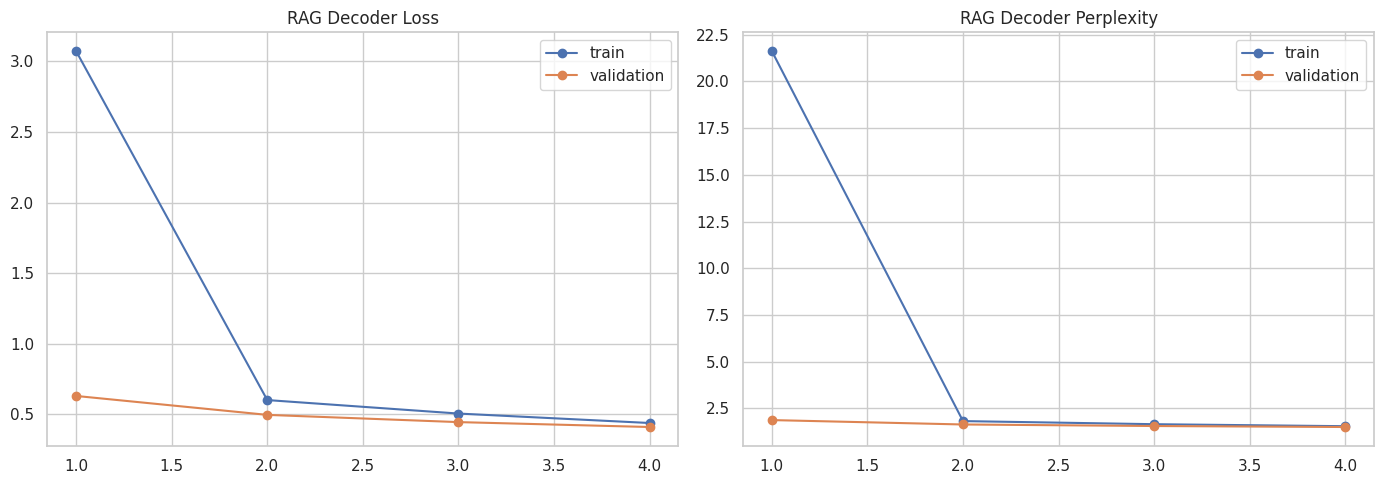

,epoch,train_loss,val_loss,train_perplexity,val_perplexity,learning_rate,epoch_seconds
0,1,3.073545,0.628351,21.618397,1.874516,0.0003,277.840810
1,2,0.599233,0.494222,1.820721,1.639223,0.0003,277.527182
2,3,0.503580,0.442951,1.654634,1.557295,0.0003,277.411207
3,4,0.436538,0.408140,1.547341,1.504018,0.0003,277.585491


  0%|          | 0/875 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Decoder epoch 01 | train ppl 20.6475 | val ppl 1.8326


  0%|          | 0/875 [00:00<?, ?it/s]

...

  0%|          | 0/188 [00:00<?, ?it/s]

Decoder epoch 03 | train ppl 1.6325 | val ppl 1.5209


  0%|          | 0/875 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Decoder epoch 04 | train ppl 1.5339 | val ppl 1.4430


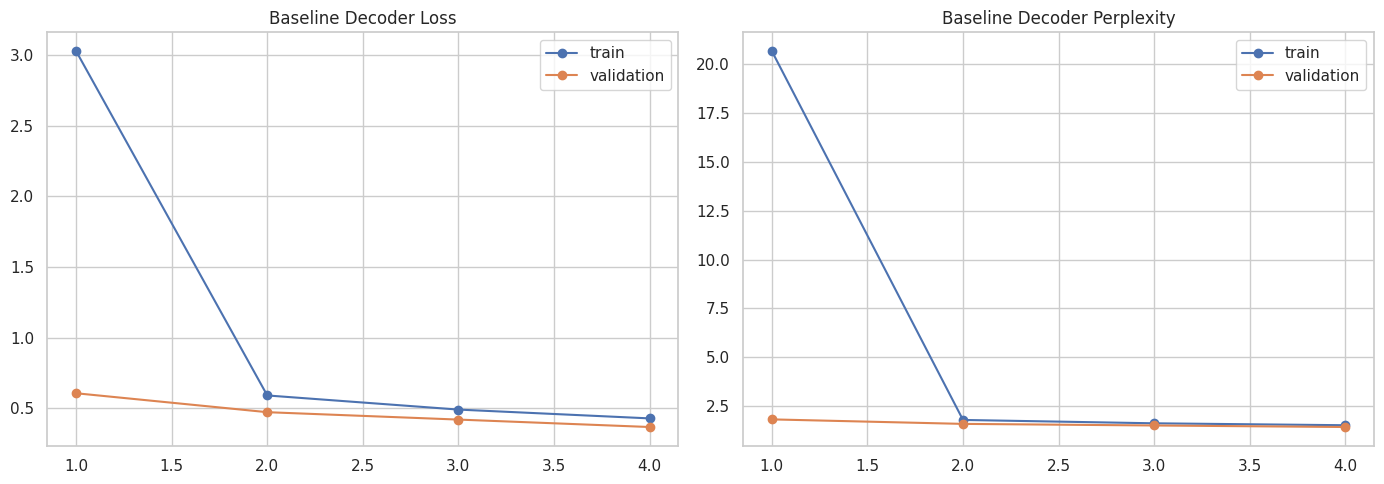

,epoch,train_loss,val_loss,train_perplexity,val_perplexity,learning_rate,epoch_seconds
0,1,3.027594,0.605720,20.647491,1.832572,0.0003,275.521272
1,2,0.590137,0.471681,1.804236,1.602686,0.0003,275.077238
2,3,0.490092,0.419335,1.632466,1.520949,0.0003,275.408437
3,4,0.427791,0.366744,1.533865,1.443028,0.0003,275.632941


In [20]:
rag_decoder = DecoderOnlyTransformer(
    vocab_size=len(decoder_vocab),
    max_len=CONFIG.decoder_max_len,
    d_model=CONFIG.d_model,
    num_heads=CONFIG.num_heads,
    num_layers=CONFIG.num_layers,
    ff_multiplier=CONFIG.ff_multiplier,
    dropout=CONFIG.dropout,
    pad_idx=decoder_vocab.pad_idx,
).to(DEVICE)

rag_history = train_language_model(rag_decoder, train_rag_loader, val_rag_loader, learning_rate=CONFIG.decoder_lr)
plot_decoder_history(rag_history, title_prefix="RAG Decoder", output_name="rag_decoder_history.png")
display(rag_history)

torch.save(
    {
        "config": asdict(CONFIG),
        "decoder_vocab": decoder_vocab.id_to_token,
        "state_dict": rag_decoder.state_dict(),
    },
    MODELS_DIR / "rag_decoder_transformer.pt",
)
rag_history.to_csv(RESULTS_DIR / "rag_decoder_history.csv", index=False)

gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

baseline_decoder = DecoderOnlyTransformer(
    vocab_size=len(decoder_vocab),
    max_len=CONFIG.decoder_max_len,
    d_model=CONFIG.d_model,
    num_heads=CONFIG.num_heads,
    num_layers=CONFIG.num_layers,
    ff_multiplier=CONFIG.ff_multiplier,
    dropout=CONFIG.dropout,
    pad_idx=decoder_vocab.pad_idx,
).to(DEVICE)

baseline_history = train_language_model(
    baseline_decoder,
    train_baseline_loader,
    val_baseline_loader,
    learning_rate=CONFIG.decoder_lr,
)
plot_decoder_history(baseline_history, title_prefix="Baseline Decoder", output_name="baseline_decoder_history.png")
display(baseline_history)

torch.save(
    {
        "config": asdict(CONFIG),
        "decoder_vocab": decoder_vocab.id_to_token,
        "state_dict": baseline_decoder.state_dict(),
    },
    MODELS_DIR / "baseline_decoder_transformer.pt",
)
baseline_history.to_csv(RESULTS_DIR / "baseline_decoder_history.csv", index=False)

In [21]:
def prettify_generated_text(text: str) -> str:
    text = re.sub(r"\s+([.,!?;:])", r"\1", text).strip()
    if not text:
        return ""
    text = text[0].upper() + text[1:]
    if text[-1] not in ".!?":
        text += "."
    return text


@torch.no_grad()
def generate_explanation(model: nn.Module, prompt_text: str, vocab: Vocabulary, max_new_tokens: int) -> str:
    model.eval()
    prompt_tokens = tokenize(prompt_text)
    input_ids = vocab.encode(["<bos>"] + prompt_tokens + ["<sep>"])
    input_ids = input_ids[: CONFIG.decoder_max_len]
    prompt_length = len(input_ids)

    for _ in range(max_new_tokens):
        current_ids = input_ids[-CONFIG.decoder_max_len :]
        current_tensor = torch.tensor([current_ids], dtype=torch.long, device=DEVICE)
        current_mask = torch.ones_like(current_tensor)
        outputs = model(current_tensor, current_mask)
        next_token_id = int(outputs["logits"][0, -1].argmax(dim=-1).item())
        if next_token_id == vocab.eos_idx:
            break
        if len(input_ids) >= CONFIG.decoder_max_len:
            break
        input_ids.append(next_token_id)

    generated_token_ids = input_ids[prompt_length:]
    return prettify_generated_text(vocab.decode(generated_token_ids))


rag_test_metrics = run_language_model_epoch(rag_decoder, test_rag_loader, optimizer=None)
baseline_test_metrics = run_language_model_epoch(baseline_decoder, test_baseline_loader, optimizer=None)

ablation_table = pd.DataFrame(
    [
        {
            "model": "RAG decoder",
            "test_loss": rag_test_metrics["loss"],
            "test_perplexity": rag_test_metrics["perplexity"],
        },
        {
            "model": "No-retrieval baseline",
            "test_loss": baseline_test_metrics["loss"],
            "test_perplexity": baseline_test_metrics["perplexity"],
        },
    ]
).round(4)

display(ablation_table)
ablation_table.to_csv(RESULTS_DIR / "decoder_ablation_metrics.csv", index=False)

example_count = min(5, len(test_decoder_df))
qualitative_rows = []
for row_index in range(example_count):
    rag_prompt = test_decoder_df.iloc[row_index]["prompt_with_retrieval"]
    baseline_prompt = test_decoder_df.iloc[row_index]["prompt_without_retrieval"]
    rag_generation = generate_explanation(rag_decoder, rag_prompt, decoder_vocab, CONFIG.max_generation_len)
    baseline_generation = generate_explanation(baseline_decoder, baseline_prompt, decoder_vocab, CONFIG.max_generation_len)
    qualitative_rows.append(
        {
            "review_id": int(test_df_pred.iloc[row_index]["review_id"]),
            "review_text": test_df_pred.iloc[row_index]["review_text"],
            "pred_sentiment": test_df_pred.iloc[row_index]["pred_sentiment"],
            "pred_length_bucket": test_df_pred.iloc[row_index]["pred_length_bucket"],
            "reference_explanation": prettify_generated_text(test_decoder_df.iloc[row_index]["target_text"]),
            "rag_generation": rag_generation,
            "baseline_generation": baseline_generation,
            "retrieved_1": train_df_pred.iloc[int(test_retrieved_idx[row_index, 0])]["review_text"],
            "retrieved_2": train_df_pred.iloc[int(test_retrieved_idx[row_index, 1])]["review_text"] if CONFIG.top_k > 1 else "",
            "retrieved_3": train_df_pred.iloc[int(test_retrieved_idx[row_index, 2])]["review_text"] if CONFIG.top_k > 2 else "",
        }
    )

qualitative_examples_df = pd.DataFrame(qualitative_rows)
qualitative_examples_df.to_csv(RESULTS_DIR / "generated_explanations_examples.csv", index=False)
display(qualitative_examples_df)

final_results_payload = {
    "config": asdict(CONFIG),
    "encoder_metrics": encoder_metrics,
    "rag_test_metrics": rag_test_metrics,
    "baseline_test_metrics": baseline_test_metrics,
    "retrieval_topk_analysis": retrieval_k_analysis.to_dict(orient="records"),
}
save_json(final_results_payload, RESULTS_DIR / "final_results_summary.json")

  0%|          | 0/188 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

,model,test_loss,test_perplexity
0,RAG decoder,0.4044,1.4984
1,No-retrieval baseline,0.3649,1.4404


,review_id,review_text,pred_sentiment,pred_length_bucket,reference_explanation,rag_generation,baseline_generation,retrieved_1,retrieved_2,retrieved_3
0,27665,I purchased this blade as I have to make a lot of things from scratch due to our special diet issues. When I first started using my Kitchen Aid I thought wouldn't it be great i...,Positive,Medium,"This review is positive because it mentions blade and thought, suggesting overall satisfaction and a favorable product experience. The review provides a moderate amount of deta...","This review is positive because it mentions like and like, suggesting overall satisfaction and a favorable product experience. the review provides a moderate amount of detail t...","This review is positive because it mentions great and great, suggesting overall satisfaction and a favorable product experience. the review provides a moderate amount of detail...","I love that these are organic, all natural products - it smells lovely! But for me, it left my hair almost heavy and greasy - I find if I use it once a week, its fine - but I c...","When I came on Amazon and read the reviews, I wasn't quite sure if they'd be totally accurate. Such quality is rarely found for so cheap. But, when I plugged these guys in, I r...",My son loves the fact he can collapse it and pack up for campouts. Have to take reel off to close it up but he figures out how to leave it rigged and still get it all in there....
1,2044,"I LOVE Turbie Twists. They are my go to every day. I use them after the shower, or at night when I want to keep my hair from getting wet when I wash my face (I'm a splasher!) T...",Positive,Medium,"This review is positive because it mentions love and turbie, suggesting overall satisfaction and a favorable product experience. The review provides a moderate amount of detail...","This review is positive because it mentions love and love, suggesting overall satisfaction and a favorable product experience. the review provides a moderate amount of detail t...","This review is positive because it mentions love and love, suggesting overall satisfaction and a favorable product experience. the review provides a moderate amount of detail t...","This water bottle does a great job of keeping water very cold, even in warm temperatures. I've had water and ice cubes in this bottle on a ride in 95 degree heat, and it was st...","Works great, reliable! I have both the Canon A530 & A560. With AA batteries you can't go wrong. Pictures are great. Worked really well on our last trip to Peru. The entire Cano...","I love this oil! I put it on my wet skin right after the shower, and just blot dry the water with a towel. It smells so fresh, and hydrates the skin without heavy oilyness. I a..."
2,5049,"Once I figured out how to open it so that the pump was active, which was easier than I was making it out to be, it worked great. I put my polish remover in it and I was able to...",Positive,Medium,"This review is positive because it mentions once and figured, suggesting overall satisfaction and a favorable product experience. The review provides a moderate amount of detai...","This review is positive because it mentions using and use, suggesting overall satisfaction and a favorable product experience. the review provides a moderate amount of detail t...","This review is positive because it mentions first and size, suggesting overall satisfaction and a favorable product experience. the review provides a moderate amount of detail ...","We bought this to use in our motorhome. We were forever running to the store to buy more bottles of water. Now, all I do if fill the pitcher and in just a few minutes, I have g...","Both cables were shipped as the same color, unlike the current amazon picture. I was happy with that. Cables work great for connecting my Intel NUC to my TV. I didn't need a lo...","I use this with my Comcast Internet service and have had no problems whatsoever in the year since I bought it. I hooked it up to my cable outle

In [22]:
import gradio as gr


def predict_single_review(review_text: str, top_k: int = 3):
    cleaned_review = clean_text(review_text)
    if len(tokenize(cleaned_review)) < 5:
        return "Review too short", "N/A", "Please provide a longer review.", pd.DataFrame()

    encoder_ids, encoder_mask = encode_encoder_text(cleaned_review, encoder_vocab, CONFIG.encoder_max_len)
    encoder_input_ids = torch.tensor([encoder_ids], dtype=torch.long, device=DEVICE)
    encoder_attention_mask = torch.tensor([encoder_mask], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        encoder_output = encoder_model(encoder_input_ids, encoder_attention_mask)
        predicted_sentiment = ID_TO_SENTIMENT[int(encoder_output["sentiment_logits"].argmax(dim=-1).item())]
        predicted_length = ID_TO_LENGTH[int(encoder_output["length_logits"].argmax(dim=-1).item())]
        query_embedding = encoder_output["embedding"].cpu().numpy()

    normalized_query = l2_normalize(query_embedding)
    retrieved_indices, retrieved_scores = batched_cosine_topk(
        normalized_query,
        train_norm_embeddings,
        top_k=min(top_k, 5),
        chunk_size=1,
        exclude_self=False,
    )
    retrieved_indices = retrieved_indices[0]
    retrieved_scores = retrieved_scores[0]
    retrieved_rows = train_df_pred.iloc[retrieved_indices].copy()
    retrieved_rows["similarity"] = retrieved_scores

    prompt_text = build_rag_prompt(
        cleaned_review,
        predicted_sentiment,
        predicted_length,
        retrieved_rows["review_text"].tolist(),
    )
    generated_explanation = generate_explanation(rag_decoder, prompt_text, decoder_vocab, CONFIG.max_generation_len)

    display_table = retrieved_rows[["category", "pred_sentiment", "pred_length_bucket", "similarity", "review_text"]].reset_index(drop=True)
    return predicted_sentiment, predicted_length, generated_explanation, display_table


demo = gr.Interface(
    fn=predict_single_review,
    inputs=[
        gr.Textbox(lines=6, label="Input review text"),
        gr.Slider(minimum=1, maximum=5, value=CONFIG.top_k, step=1, label="Top-k retrieved reviews"),
    ],
    outputs=[
        gr.Textbox(label="Predicted sentiment"),
        gr.Textbox(label="Predicted length bucket"),
        gr.Textbox(label="Generated explanation"),
        gr.Dataframe(label="Retrieved supporting reviews"),
    ],
    title="Amazon Review Transformer + RAG Demo",
    description="Bonus interactive demo: classify a review, retrieve similar reviews, and generate a grounded explanation.",
)

demo.launch(share=False, debug=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
